In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, r2_score
from sklearn.utils import class_weight
from tensorflow.keras import layers, models, optimizers 
# Set global seeds for total reproducibility
SEED = 42 
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Environment ready. TensorFlow version: {tf.version.VERSION}")
print(f"GPU detected: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1777934354.989683     861 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777934356.160562     861 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777934360.077849     861 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Environment ready. TensorFlow version: 2.21.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


This cell locks down the randomness of the universe so your GPU produces the same results every time you run it.

This cell initializes the environment and ensures that the random weight initialization and data splitting are consistent across every run. It also confirms that the NVIDIA GPU is recognized by TensorFlow.

In [2]:


class DataAugmentor:
    def __init__(self, rotation=15, width_shift=0.1, height_shift=0.1, zoom=0.1):
        # We slightly reduced the intensity to keep facial features recognizable
        self.rotation = rotation
        self.width_shift = width_shift
        self.height_shift = height_shift
        self.zoom = zoom

    def get_train_generator(self):
        """Returns a generator for training with brightness and geometric augmentation."""
        return ImageDataGenerator(
            rescale=1./255,
            rotation_range=self.rotation,
            width_shift_range=self.width_shift,
            height_shift_range=self.height_shift,
            brightness_range=[0.8, 1.2], # HELPS WITH CAMERA SHADOWS
            shear_range=0.1,
            zoom_range=self.zoom,
            horizontal_flip=True,
            fill_mode='nearest',
            validation_split=0.2
        )

    def get_val_generator(self):
        """Returns a clean generator for validation (rescale only)."""
        # Validation data must ONLY be rescaled, never augmented
        return ImageDataGenerator(
            rescale=1./255, 
            validation_split=0.2
        )

The DataAugmentor Class
This class creates the "recipe" for transforming your data to prevent the model from memorizing specific images.

The DataAugmentor class handles the artificial expansion of our dataset. By slightly rotating and shifting images, we force the CNN to learn general facial features rather than specific pixel locations, which significantly reduces overfitting.

In [3]:
import os
import pandas as pd
from glob import glob # This allows searching through subfolders

class DataLoader:
    def __init__(self, path, seed=42):
        self.path = path
        self.seed = seed
        self.df = None

    def prepare_data(self):
        # 1. SEARCH SUBFOLDERS
        # This looks for all .jpg files inside the path and any sub-folders
        search_pattern = os.path.join(self.path, "**", "*.jpg")
        files = glob(search_pattern, recursive=True)
        
        if not files:
            print(f"❌ Error: No .jpg files found in '{self.path}' or its subfolders.")
            if os.path.exists(self.path):
                print(f"📂 Folders seen: {os.listdir(self.path)}")
            return

        data = []
        for file_path in files:
            # Extract just the filename to get the age
            f = os.path.basename(file_path)
            try:
                age = int(f.split('_')[0])
                
                if age <= 18: label = 'Child'
                elif age <= 30: label = 'Young Adult'
                elif age <= 55: label = 'Adult'
                else: label = 'Senior'
                
                # We store 'file_path' so the generator knows exactly where to look
                data.append({'filename': file_path, 'age': age, 'label': label})
            except (ValueError, IndexError):
                continue
        
        self.df = pd.DataFrame(data)
        self.df = self.df.sample(frac=1, random_state=self.seed).reset_index(drop=True)
        
        print(f"✅ Successfully found {len(self.df)} images across all subfolders.")

The DataLoader Class
This handles the heavy lifting of reading your UTKFace folder and creating the Age categories.

The DataLoader class scans the directory and parses the UTKFace naming convention (Age_Gender_Race_Date). It creates a structured Pandas DataFrame that maps every image to its specific age group

In [4]:
class DataVisualizer:
    def __init__(self, data_loader):
        self.df = data_loader.df
        # Set a clean, professional aesthetic for all plots
        sns.set_theme(style="whitegrid")

    def plot_stats(self):
        """Generates professional distribution plots for age and categories."""
        plt.figure(figsize=(15, 6))
        
        # 1. Age Distribution (Continuous)
        plt.subplot(1, 2, 1)
        sns.histplot(self.df['age'], bins=20, kde=True, color="#2c3e50")
        plt.title('Demographic Age Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Age (Years)')
        plt.ylabel('Frequency')

        # 2. Category Distribution (Discrete)
        plt.subplot(1, 2, 2)
        # Using a professional palette for different age groups
        order = ['Child', 'Young Adult', 'Adult', 'Senior']
        sns.countplot(data=self.df, x='label', order=order, palette="viridis")
        plt.title('Age Group Categorization', fontsize=14, fontweight='bold')
        plt.xlabel('Category')
        plt.ylabel('Count')
        
        plt.tight_layout()
        plt.show()

    def show_samples(self, generator, is_regression=False):
        """Displays 9 sample images from the generator with their ground truth labels."""
        images, labels = next(generator)
        plt.figure(figsize=(12, 12))
        
        for i in range(min(9, len(images))):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i])
            
            # Logic to handle different label types (one-hot vs raw number)
            if is_regression:
                label_text = f"Age: {labels[i]:.1f}"
            else:
                # Get the category name from the one-hot encoded vector
                class_idx = np.argmax(labels[i])
                # Map index back to names (Child, Young Adult, etc.)
                label_text = f"Class: {class_idx}" 
                
            plt.title(label_text, fontsize=12, color='darkred')
            plt.axis('off')
            
        plt.suptitle("Augmented Data Batch Samples", fontsize=16, fontweight='bold')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

The DataVisualizer Class
Your sanity check to make sure the data looks correct before training starts.

The DataVisualizer provides a statistical overview of our dataset and allows us to inspect a batch of images. This ensures the labels assigned by the DataLoader actually match the faces we are seeing.

In [5]:
class ModelManager:
    def __init__(self, folder="saved_models"):
        """Initializes the directory structure for model persistence."""
        self.folder = folder
        if not os.path.exists(self.folder): 
            os.makedirs(self.folder)
            print(f"📁 Created directory: {self.folder}")

    def save_all(self, model, history, name):
        """
        Saves the model weights and training history with detailed feedback.
        Useful for comparing Classification vs. Regression results later.
        """
        model_path = os.path.join(self.folder, f"{name}.keras")
        history_path = os.path.join(self.folder, f"{name}_history.csv")
        
        try:
            # Save the full model in high-fidelity Keras format
            model.save(model_path)
            
            # Save history to CSV for later visualization in README or LinkedIn
            history_df = pd.DataFrame(history.history)
            history_df.to_csv(history_path, index=False)
            
            print("-" * 30)
            print(f"✅ EXPORT SUCCESSFUL: {name}")
            print(f"📍 Model: {model_path}")
            print(f"📍 History: {history_path}")
            print("-" * 30)
        except Exception as e:
            print(f"❌ Error saving model '{name}': {e}")

    def load(self, name):
        """Loads a saved Keras model from the disk with path validation."""
        path = os.path.join(self.folder, f"{name}.keras")
        if os.path.exists(path):
            print(f"🔄 Loading model architecture and weights from {path}...")
            # Note: If using custom loss/metrics, they would be handled here
            return tf.keras.models.load_model(path)
        else:
            print(f"⚠️ Warning: Model file '{path}' not found.")
            return None

The ModelManager Class
This class manages your hard drive, handling saving and reloading.

The ModelManager provides a clean interface for disk operations. It separates the model's weights from the training code, allowing for easy versioning and recovery.

In [6]:
class ModelTrainer:
    def __init__(self, model_obj, loader, augmentor, manager):
        self.model_wrapper = model_obj
        self.loader = loader
        self.aug = augmentor
        self.manager = manager

    def run(self, epochs=10, model_name="mobilenet_classification"):
        print(f"🚀 Starting Classification Training: {model_name}")
        
        # directory=None is used because filename now contains the FULL path
        train_gen = self.aug.get_train_generator().flow_from_dataframe(
            self.loader.df, directory=None, x_col='filename', y_col='label',
            target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training'
        )
        
        val_gen = self.aug.get_val_generator().flow_from_dataframe(
            self.loader.df, directory=None, x_col='filename', y_col='label',
            target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation', shuffle=False
        )

        history = self.model_wrapper.model.fit(
            train_gen, validation_data=val_gen, epochs=epochs,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
        )
        
        self.manager.save_all(self.model_wrapper.model, history, model_name)
        return history, train_gen, val_gen

The ModelTrainer Class
The Master Control that connects everything.

The ModelTrainer is the engine of the project. It orchestrates the flow of data through the augmentor and into the model, while monitoring performance and triggering the ModelManager to save the results automatically.

In [7]:
class ModelTrainerRegression:
    def __init__(self, model_obj, loader, augmentor, manager):
        self.model_wrapper = model_obj
        self.loader = loader
        self.aug = augmentor
        self.manager = manager

    def run(self, epochs=10, model_name="mobilenet_regression"):
        print(f"🚀 Starting Regression Training: {model_name}")
        
        # directory=None is used because filename now contains the FULL path
        train_gen = self.aug.get_train_generator().flow_from_dataframe(
            self.loader.df, directory=None, x_col='filename', y_col='age',
            target_size=(224, 224), batch_size=32, class_mode='raw', subset='training'
        )
        
        val_gen = self.aug.get_val_generator().flow_from_dataframe(
            self.loader.df, directory=None, x_col='filename', y_col='age',
            target_size=(224, 224), batch_size=32, class_mode='raw', subset='validation', shuffle=False
        )

        history = self.model_wrapper.model.fit(
            train_gen, validation_data=val_gen, epochs=epochs,
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
        )
        
        self.manager.save_all(self.model_wrapper.model, history, model_name)
        return history, train_gen, val_gen

In [8]:
class ModelEvaluator:
    """Professional Evaluation for Classification (Unfrozen MobileNet)"""
    def __init__(self, model_wrapper, train_gen, val_gen):
        self.model = model_wrapper.model
        self.val_gen = val_gen
        self.class_names = list(train_gen.class_indices.keys())

    def run_full_evaluation(self, history):
        # 1. Training Performance Curves
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ecc71', lw=2)
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#e74c3c', lw=2)
        plt.title('Classification Accuracy Trend', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Training Loss', color='#2ecc71', lw=2)
        plt.plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', lw=2)
        plt.title('Cross-Entropy Loss Trend', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.legend()
        plt.show()

        # 2. Confusion Matrix Analysis
        print("\n" + "="*40)
        print("🔍 GENERATING CONFUSION MATRIX...")
        self.val_gen.reset()
        y_pred_probs = self.model.predict(self.val_gen)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = self.val_gen.classes

        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Confusion Matrix: Model Error Analysis', fontsize=14, fontweight='bold')
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.show()
        
        print("\n📋 DETAILED CLASSIFICATION REPORT:")
        print(classification_report(y_true, y_pred, target_names=self.class_names))


class ModelEvaluatorRegression:
    """Professional Evaluation for Age Regression"""
    def __init__(self, model_wrapper, val_gen):
        self.model = model_wrapper.model
        self.val_gen = val_gen

    def run_full_evaluation(self, history):
        # 1. Regression Metrics Curves
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.plot(history.history['mae'], label='Train MAE', color='#3498db', lw=2)
        plt.plot(history.history['val_mae'], label='Val MAE', color='#e67e22', lw=2)
        plt.title('Mean Absolute Error (Years)', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'], label='Train Loss (MSE)', color='#3498db', lw=2)
        plt.plot(history.history['val_loss'], label='Val Loss (MSE)', color='#e67e22', lw=2)
        plt.title('Mean Squared Error Trend', fontsize=14, fontweight='bold')
        plt.xlabel('Epochs')
        plt.legend()
        plt.show()

        # 2. Predicted vs. Actual Analysis
        print("\n" + "="*40)
        print("🔍 GENERATING REGRESSION ANALYSIS...")
        self.val_gen.reset()
        y_true = self.val_gen.labels
        y_pred = self.model.predict(self.val_gen).flatten()

        # 3. Scatter Plot with Identity Line
        plt.figure(figsize=(10, 6))
        plt.scatter(y_true, y_pred, alpha=0.4, color='#3498db')
        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', lw=2)
        plt.title('Actual Age vs. Predicted Age (Linear Regression Analysis)', fontsize=14, fontweight='bold')
        plt.xlabel('Actual Ground Truth Age')
        plt.ylabel('Model Prediction')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

        # 4. Error Statistics
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        print(f"\n📊 PERFORMANCE SUMMARY:")
        print(f"Mean Absolute Error (MAE): {mae:.2f} years")
        print(f"R-squared Score (R2):      {r2:.4f}")
        print("="*40)

The ModelEvaluator Class
Place this cell right after your ModelTrainer and before your final execution.

The ModelEvaluator class provides a standardized way to measure model performance. It goes beyond simple accuracy by calculating the Confusion Matrix and F1-scores, which are essential for understanding if the model has a bias toward specific age groups.

✅ Successfully found 66976 images across all subfolders.


/tmp/ipykernel_8713/897749610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, x='label', order=order, palette="viridis")


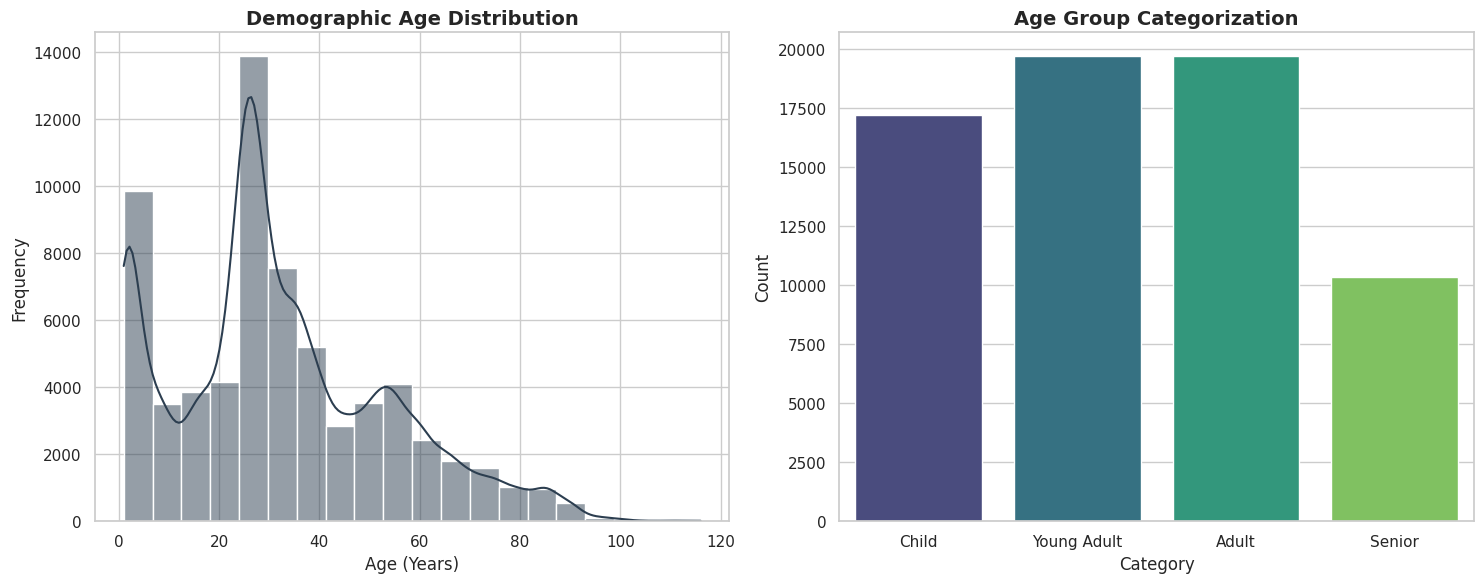


--- Phase 1: Classification Training ---
🚀 Starting Classification Training: age_classifier_final
Found 53581 validated image filenames belonging to 4 classes.
Found 13395 validated image filenames belonging to 4 classes.
Epoch 1/15


I0000 00:00:1777922467.253907    8713 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777922472.604289   12497 service.cc:153] XLA service 0x7a64ec046370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777922472.604323   12497 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 12.9.0; Runtime: 12.3.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777922472.752605   12497 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777922473.739249   12497 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777922473.861221   12497 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15604__.150
I0000 00:00:1777922490.576386   12497 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the

 212/1675 ━━━━━━━━━━━━━━━━━━━━ 5:30 226ms/step - accuracy: 0.3936 - loss: 1.4224

I0000 00:00:1777922540.445729   12496 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15604__.150


1675/1675 ━━━━━━━━━━━━━━━━━━━━ 449s 253ms/step - accuracy: 0.6007 - loss: 0.9239 - val_accuracy: 0.6792 - val_loss: 0.7464
Epoch 2/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 369s 220ms/step - accuracy: 0.6692 - loss: 0.7681 - val_accuracy: 0.7150 - val_loss: 0.6650
Epoch 3/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 386s 231ms/step - accuracy: 0.6907 - loss: 0.7154 - val_accuracy: 0.7302 - val_loss: 0.6330
Epoch 4/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 387s 231ms/step - accuracy: 0.7088 - loss: 0.6779 - val_accuracy: 0.7389 - val_loss: 0.6064
Epoch 5/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 346s 207ms/step - accuracy: 0.7215 - loss: 0.6534 - val_accuracy: 0.7457 - val_loss: 0.5918
Epoch 6/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 359s 215ms/step - accuracy: 0.7315 - loss: 0.6276 - val_accuracy: 0.7502 - val_loss: 0.5799
Epoch 7/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 391s 233ms/step - accuracy: 0.7362 - loss: 0.6122 - val_accuracy: 0.7619 - val_loss: 0.5606
Epoch 8/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 397s 237ms/step - accuracy: 0.7

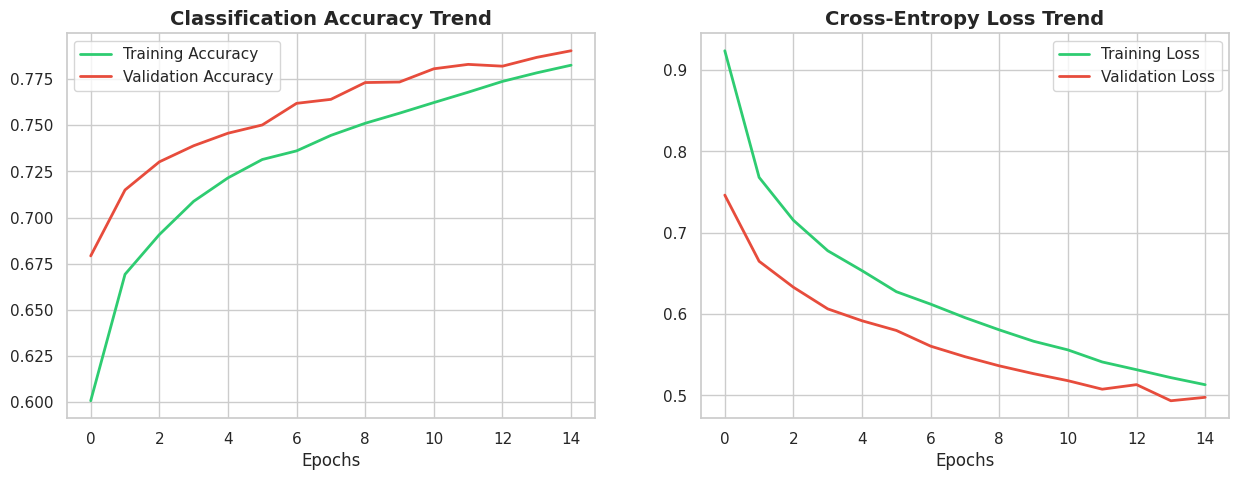


🔍 GENERATING CONFUSION MATRIX...
419/419 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step


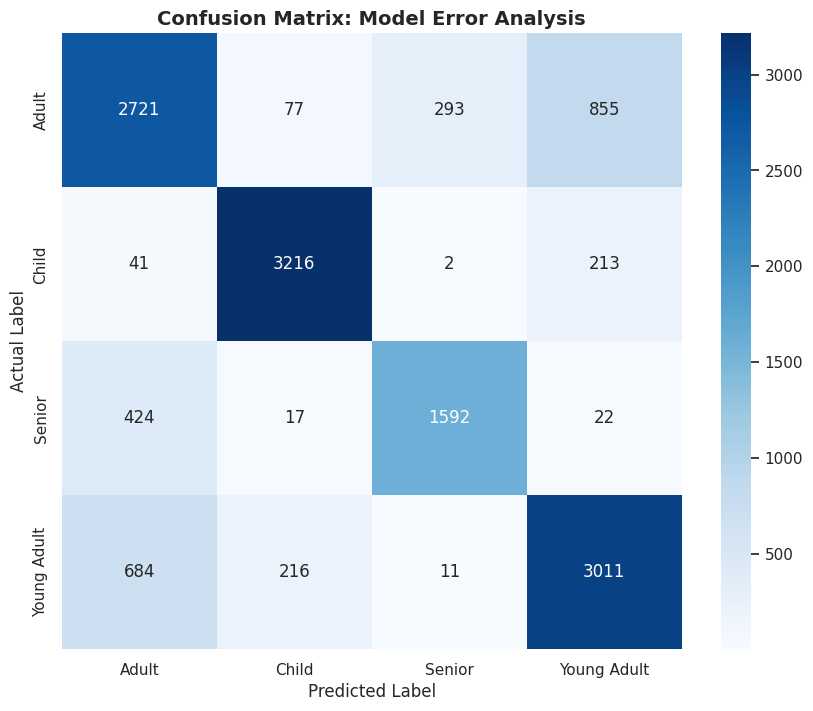


📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       Adult       0.70      0.69      0.70      3946
       Child       0.91      0.93      0.92      3472
      Senior       0.84      0.77      0.81      2055
 Young Adult       0.73      0.77      0.75      3922

    accuracy                           0.79     13395
   macro avg       0.80      0.79      0.79     13395
weighted avg       0.79      0.79      0.79     13395


--- Phase 2: Regression Training ---
🚀 Starting Regression Training: age_regression_final
Found 53581 validated image filenames.
Found 13395 validated image filenames.
Epoch 1/15


I0000 00:00:1777928197.299677   12497 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_166950__.115


 125/1675 ━━━━━━━━━━━━━━━━━━━━ 5:49 226ms/step - loss: 565.6245 - mae: 18.2525

I0000 00:00:1777928229.840637   12495 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_166950__.115


1675/1675 ━━━━━━━━━━━━━━━━━━━━ 434s 254ms/step - loss: 193.0408 - mae: 10.3799 - val_loss: 148.8250 - val_mae: 9.1443
Epoch 2/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 389s 232ms/step - loss: 158.9111 - mae: 9.3250 - val_loss: 145.9425 - val_mae: 8.9026
Epoch 3/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 373s 222ms/step - loss: 152.8863 - mae: 9.1284 - val_loss: 136.5501 - val_mae: 8.5669
Epoch 4/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 350s 209ms/step - loss: 147.9664 - mae: 8.9877 - val_loss: 134.0329 - val_mae: 8.6054
Epoch 5/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 372s 222ms/step - loss: 145.4699 - mae: 8.9042 - val_loss: 129.9930 - val_mae: 8.4303
Epoch 6/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 396s 237ms/step - loss: 143.9874 - mae: 8.8526 - val_loss: 136.1892 - val_mae: 8.6357
Epoch 7/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 385s 230ms/step - loss: 142.6040 - mae: 8.7853 - val_loss: 131.7626 - val_mae: 8.5384
Epoch 8/15
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 360s 215ms/step - loss: 140.3176 - mae: 8.7527 - val_loss: 131.3663 - va

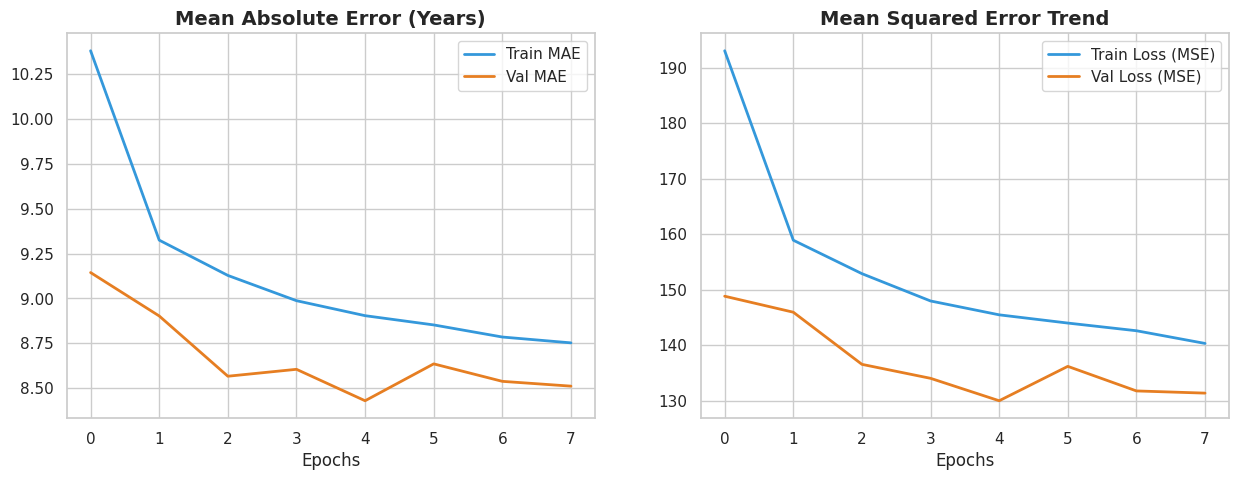


🔍 GENERATING REGRESSION ANALYSIS...
419/419 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step


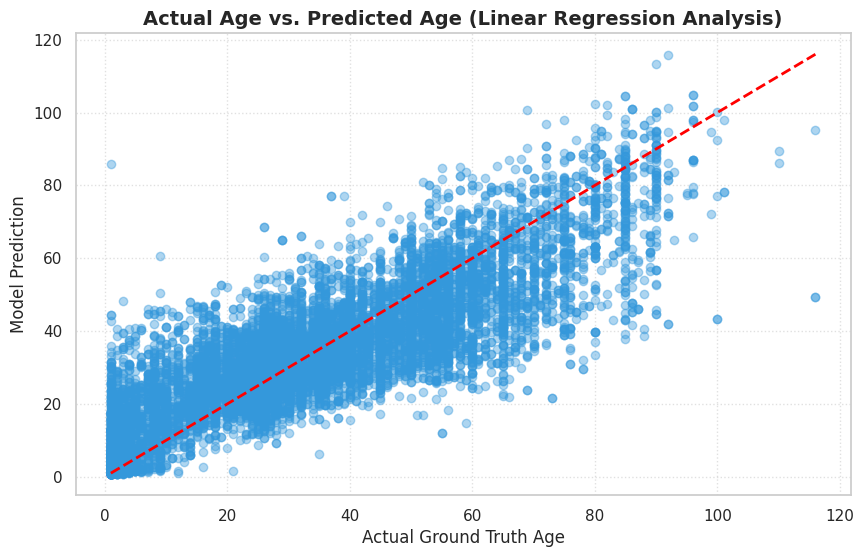


📊 PERFORMANCE SUMMARY:
Mean Absolute Error (MAE): 8.43 years
R-squared Score (R2):      0.7182


In [28]:
# 1. SETUP & DATA LOADING
# Use the top-level folder (e.g., "/content/data")
dataset_path = "//home/mamdouh_salem/data" 

loader = DataLoader(path=dataset_path)
loader.prepare_data()

# Only proceed if data was actually found
if loader.df is not None:
    # Initialize Support Infrastructure
    augmentor = DataAugmentor()
    manager = ModelManager(folder="saved_models")
    visualizer = DataVisualizer(loader)

    # Professional Visual Check (Ensures labels are correct)
    visualizer.plot_stats()
    
    # ---------------------------------------------------------
    # 2. CLASSIFICATION: FINE-TUNING (UNFROZEN)
    # ---------------------------------------------------------
    print("\n--- Phase 1: Classification Training ---")
    class_model = MobileNetClassificationUnfrozen(num_classes=4)
    trainer_class = ModelTrainer(class_model, loader, augmentor, manager)
    
    # This will save as: saved_models/age_classifier_final.keras
    history_c, train_c, val_c = trainer_class.run(
        epochs=15, 
        model_name="age_classifier_final"
    )
    
    # Run Evaluation for Classification
    eval_c = ModelEvaluator(class_model, train_c, val_c)
    eval_c.run_full_evaluation(history_c)

    # ---------------------------------------------------------
    # 3. REGRESSION: CONTINUOUS AGE PREDICTION
    # ---------------------------------------------------------
    print("\n--- Phase 2: Regression Training ---")
    reg_model = MobileNetRegression()
    trainer_reg = ModelTrainerRegression(reg_model, loader, augmentor, manager)
    
    # This will save as: saved_models/age_regression_final.keras
    history_r, train_r, val_r = trainer_reg.run(
        epochs=15, 
        model_name="age_regression_final"
    )
    
    # Run Evaluation for Regression
    eval_r = ModelEvaluatorRegression(reg_model, val_r)
    eval_r.run_full_evaluation(history_r)

else:
    print("🛑 ERROR: No data loaded. Check if the 'dataset_path' matches your folder in the explorer.")

In [9]:
class MobileNetRegression:
    def __init__(self):
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet', include_top=False, input_shape=(224, 224, 3)
        )
        base_model.trainable = False 

        self.model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(1, activation='linear')
        ])

        self.model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [10]:
class MobileNetClassificationUnfrozen:
    def __init__(self, num_classes=4):
        # 1. Load the pre-trained base
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet', include_top=False, input_shape=(224, 224, 3)
        )
        
        # 2. Unfreeze the last 20 layers for fine-tuning
        base_model.trainable = True
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        # 3. Build the classification head
        self.model = models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.Dropout(0.3),
            layers.Dense(num_classes, activation='softmax')
        ])
        
        # 4. Compile with a lower learning rate for stability during fine-tuning
        self.model.compile(
            optimizer=optimizers.Adam(learning_rate=1e-5), 
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

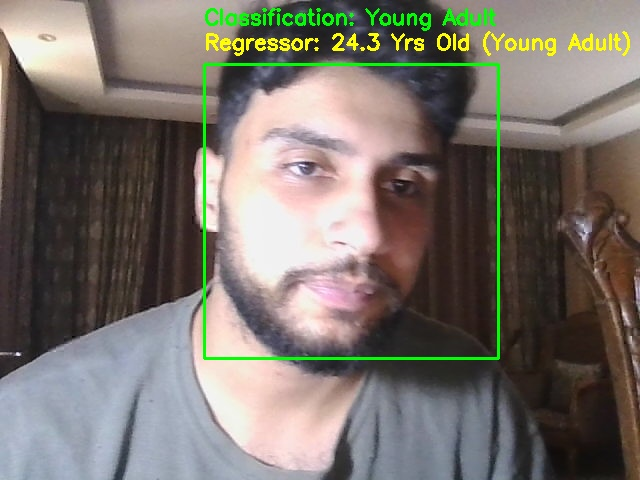

Camera hardware successfully released.


KeyboardInterrupt: 

In [27]:
import cv2
import numpy as np
import tensorflow as tf
import time  # <--- Added this to fix the NameError
from collections import deque
from IPython.display import display, Image, clear_output

# 1. Load your models (Classification: 79% Acc | Regression: 8.4 MAE)
classifier = tf.keras.models.load_model('saved_models/age_classifier_final.keras')
regressor = tf.keras.models.load_model('saved_models/age_regression_final.keras')
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Buffer for 20 frames to smooth the age jumps (20 to 30 range)
age_history = deque(maxlen=20) 
class_labels = ['Adult', 'Child', 'Senior', 'Young Adult']

def get_age_category(numeric_age):
    if numeric_age <= 18: return 'Child'
    elif numeric_age <= 30: return 'Young Adult'
    elif numeric_age <= 55: return 'Adult'
    else: return 'Senior'

# 2. Open Camera with the WSL2 V4L2 Backend
cap = cv2.VideoCapture(0, cv2.CAP_V4L2)
cap.set(cv2.CAP_PROP_FOURCC, cv2.VideoWriter_fourcc(*'MJPG'))

print("Waking up camera hardware...")
time.sleep(2) # Fixed: 'time' is now defined

if not cap.isOpened():
    print("Error: Camera still timed out. Check 'usbipd' on Windows.")
else:
    try:
        while True:
            # Clear old frames from the buffer
            for _ in range(3):
                cap.grab()
                
            ret, frame = cap.read()
            if not ret: 
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            faces = face_cascade.detectMultiScale(gray, 1.1, 8)

            for (x, y, w, h) in faces:
                # Draw the bounding box
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                
                # Crop face for MobileNetV2 input
                face_roi = frame[y:y+h, x:x+w]
                if face_roi.size > 0:
                    blob = cv2.resize(face_roi, (224, 224))
                    blob = np.expand_dims(blob, axis=0) / 255.0

                    # Run both models
                    c_raw = classifier.predict(blob, verbose=0)
                    r_raw = float(regressor.predict(blob, verbose=0)[0][0])
                    
                    # Smooth the age result to stop the 20-30 jumps
                    age_history.append(r_raw)
                    avg_age = sum(age_history) / len(age_history)
                    
                    label = class_labels[np.argmax(c_raw)]
                    reg_cat = get_age_category(avg_age)

                    # Updated Labels for clear display
                    cv2.putText(frame, f"Classification: {label}", (x, y-40), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                    cv2.putText(frame, f"Regressor: {avg_age:.1f} Yrs Old ({reg_cat})", (x, y-15), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

            # Output the processed frame to the Jupyter cell
            _, encoded = cv2.imencode('.jpg', frame)
            clear_output(wait=True)
            display(Image(data=encoded))

    except Exception as e:
        print(f"Captured Error: {e}")
    finally:
        cap.release()
        print("Camera hardware successfully released.")